In [38]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.modeling import models, fitting

from astropy.wcs import WCS
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 6
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 6
plt.rcParams["contour.linewidth"] =3

def fit_gaussian_2d(fitsfile, tied_radii=True):
    # Load FITS image
    hdu = fits.open(fitsfile)[0]
    ps = np.abs(hdu.header["CDELT1"] * 3600.0  )    # arcsec per pixel
    data = hdu.data
    data=data#-np.median(data)
    wcs1 = WCS(hdu.header)
    # Remove NaNs and Infs
    mask = np.isfinite(data)
    data_clean = np.where(mask, data, 0.0)

    # Coordinate grid
    y, x = np.indices(data.shape)

    # Initial guesses
    amp0 = np.nanmax(data_clean)
    y0, x0 = np.unravel_index(np.nanargmax(data_clean), data_clean.shape)
    sigma0 = 1  # generic width estimate

    # ----------------------------
    #  Build Gaussian Model
    # ----------------------------
    if tied_radii:
        g_init = models.Gaussian2D(amplitude=amp0,
                                   x_mean=x0,
                                   y_mean=y0,
                                   x_stddev=sigma0,
                                   y_stddev=sigma0)
        # Tie: y_stddev follows x_stddev
        g_init.y_stddev.tied = lambda m: m.x_stddev
    else:
        g_init = models.Gaussian2D(amplitude=amp0,
                                   x_mean=x0,
                                   y_mean=y0,
                                   x_stddev=sigma0,
                                   y_stddev=sigma0)

    # ----------------------------
    #  Fit the model
    # ----------------------------
    fitter = fitting.LevMarLSQFitter()
    g_fit = fitter(g_init, x, y, data_clean, filter_non_finite=True)

    model = g_fit(x, y)
    residual = data_clean - model

    # ----------------------------
    #  Print results (with FWHM)
    # ----------------------------
    print("=== Fit Results ===")
    print(f"Amplitude: {g_fit.amplitude.value:.4g}")
    print(f"Center (x, y): ({g_fit.x_mean.value:.3f}, {g_fit.y_mean.value:.3f})")
    print(f"Sigma_x (pixels): {g_fit.x_stddev.value:.3f}")
    print(f"Sigma_y (pixels): {g_fit.y_stddev.value:.3f}")

    fwhm_x = 2.3548 * g_fit.x_stddev.value * ps
    fwhm_y = 2.3548 * g_fit.y_stddev.value * ps
    print(f"FWHM_x: {fwhm_x:.3f} arcsec")
    print(f"FWHM_y: {fwhm_y:.3f} arcsec")
    skycoord = wcs1.pixel_to_world(g_fit.x_mean.value, g_fit.y_mean.value)
    print(skycoord)

    # ----------------------------
    #  Plot Original / Model / Residual
    # ----------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': wcs1})
    
    im0 = axes[0].imshow(data_clean, origin='lower',vmin=-1,vmax=3,cmap='bwr')
    axes[0].set_title("Observed 14 $\mu$m")

    im1 = axes[1].imshow(model, origin='lower',vmin=-1,vmax=3,cmap='bwr')
    axes[1].set_title("Model")

    im2 = axes[2].imshow(residual, origin='lower',vmin=-1,vmax=3,cmap='bwr')
    axes[2].set_title("Residual")

    # Adjust layout so colorbar fits below all panels
    fig.subplots_adjust(bottom=0.15, wspace=0.25)

    # Create ONE colorbar for all three plots (use last image)
    cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.03])  # [left, bottom, width, height]
    cbar = fig.colorbar(im0, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Jy $\\times$ m sr$^{-1}$")

    for ax in axes:
        ra = ax.coords["ra"]
        dec = ax.coords["dec"]
        ra.set_ticks_visible(False)
        ra.set_ticklabel_visible(False)
        dec.set_ticks_visible(False)
        dec.set_ticklabel_visible(False)
        ra.set_axislabel("")
        dec.set_axislabel("")
        
        # Create an overlay with relative coordinates
        aframe = skycoord.skyoffset_frame()
        overlay = ax.get_coords_overlay(aframe)
        ra_offset = overlay["lon"]
        dec_offset = overlay["lat"]
        
        
        
        dec_offset.set_axislabel(f"Offset Dec (arcsec)")
        ra_offset.set_axislabel("Offset RA (arcsec) ")
        
        ra_offset.set_major_formatter("s")
        dec_offset.set_major_formatter("s")
        ra_offset.set_ticks_position("b")
        ra_offset.set_ticklabel_position("b")
        dec_offset.set_ticks_position("l")
        dec_offset.set_ticklabel_position("l")
        ra_offset.set_axislabel_position("b")
        dec_offset.set_axislabel_position("l")
        
        ax.set_ylim(g_fit.y_mean.value-(3/np.abs(ps)),g_fit.y_mean.value+(3/np.abs(ps)))
        ax.set_xlim(g_fit.x_mean.value-(3/np.abs(ps)),g_fit.x_mean.value+(3/np.abs(ps)))


    plt.tight_layout()
    
    plt.savefig('Gaus_14.png',bbox_inches='tight')
    plt.show()
    return skycoord


<>:88: SyntaxWarning: invalid escape sequence '\m'
<>:88: SyntaxWarning: invalid escape sequence '\m'
/var/folders/lr/j2hz1s0d0pn69_gzyyfbcdm00000gq/T/ipykernel_89966/204270615.py:88: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title("Observed 14 $\mu$m")


Set OBSGEO-B to   -36.860883 from OBSGEO-[XYZ].
Set OBSGEO-H to 1724561055.615 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/var/folders/lr/j2hz1s0d0pn69_gzyyfbcdm00000gq/T/ipykernel_89966/204270615.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


=== Fit Results ===
Amplitude: 5.986
Center (x, y): (28.881, 26.709)
Sigma_x (pixels): 1.374
Sigma_y (pixels): 1.374
FWHM_x: 0.647 arcsec
FWHM_y: 0.647 arcsec
<SkyCoord (ICRS): (ra, dec) in deg
    (247.09010762, -24.60669595)>


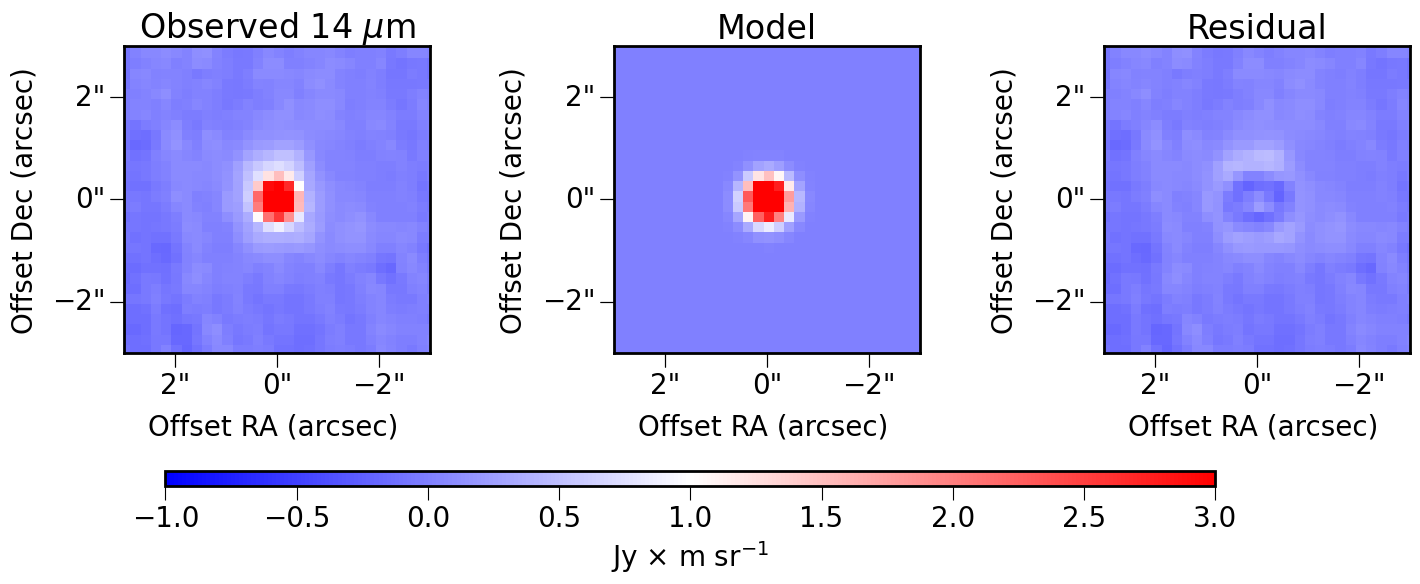

In [40]:
coord1 = fit_gaussian_2d("Cont14.fits", tied_radii=True)


In [20]:
coord1.to_string('hmsdms', precision=3) 

'16h28m21.626s -24d36m24.105s'

In [42]:
lam=5.34
FWHM = 0.033*lam + 0.106
print(FWHM)

0.28222


In [4]:
(0.647**2 - 0.568**2)**0.5

0.3098144606050532

In [5]:
#16 28 21. 615, 24 36 24. 33

16 28 21. 615, 24 36 24. 33

In [6]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# Example coordinates

ra2, dec2 = "16h28m21.615s", "-24d36m24.33s"

# Create SkyCoord objects

coord2 = SkyCoord(ra2, dec2, frame='icrs')

# Compute separation
sep = coord1.separation(coord2)  # returns an Angle object
print(f"Separation: {sep.arcsec:.3f} arcsec")

delta_ra = (coord2.ra - coord1.ra).to(u.arcsec) * np.cos(coord1.dec.radian)  # correct for declination
delta_dec = (coord2.dec - coord1.dec).to(u.arcsec)

print(f"ΔRA: {delta_ra:.3f} arcsec")
print(f"ΔDec: {delta_dec:.3f} arcsec")

Separation: 0.269 arcsec
ΔRA: -0.148 arcsec arcsec
ΔDec: -0.225 arcsec arcsec


In [15]:
x=5.51
0.033*x + 0.106

0.28783